In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
transform  = transforms.ToTensor() # For tensor conversion

train_dataset = datasets.MNIST(
    root='./MNIST_data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    shuffle=True)



In [5]:
class SparseAutoencoder(nn.Module):
    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 1000),
            nn.ReLU(),
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Linear(500, 250), # Bottleneck
            nn.ReLU(),
            nn.Linear(250,30),
            nn.Sigmoid()

        )

        self.decoder = nn.Sequential(
            nn.Linear(30, 250),
            nn.ReLU(),
            nn.Linear(250, 500),
            nn.ReLU(),
            nn.Linear(500, 1000),
            nn.ReLU(),
            nn.Linear(1000, 784),
            nn.Sigmoid()
        )

    def forward(self,x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent
    

In [6]:
def KL_divergence(latent):
    rho = 0.05
    eps = 1e-8
    rho_hat  =latent.mean(dim=0)
    rho_hat = torch.clamp(rho_hat, eps, 1-eps)
    kl = rho * torch.log(rho / rho_hat) + (1-rho)*torch.log((1-rho)/(1-rho_hat))
    return kl.sum()

In [7]:
model  = SparseAutoencoder().to(device = device)
criterion = nn.MSELoss()
optimizer = optim.Adam(params=model.parameters(), lr = 0.001)

beta = 0.0001


for epoch in range(10):
    total_loss = 0
    for images, _ in train_loader:
        images = images.view(images.size(0), -1).to(device) # reshaping
        outputs, latent = model(images)
        reconstructed_loss = criterion(outputs, images) # Reconstructed loss
        sparsity_loss = KL_divergence(latent=latent)
        loss = reconstructed_loss + beta*sparsity_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch: [{epoch+1}/10] Loss: {avg_loss:.4f}")
print("Complete Training")


Epoch: [1/10] Loss: 0.0373
Epoch: [2/10] Loss: 0.0227
Epoch: [3/10] Loss: 0.0199
Epoch: [4/10] Loss: 0.0180
Epoch: [5/10] Loss: 0.0168
Epoch: [6/10] Loss: 0.0160
Epoch: [7/10] Loss: 0.0154
Epoch: [8/10] Loss: 0.0149
Epoch: [9/10] Loss: 0.0145
Epoch: [10/10] Loss: 0.0141
Complete Training


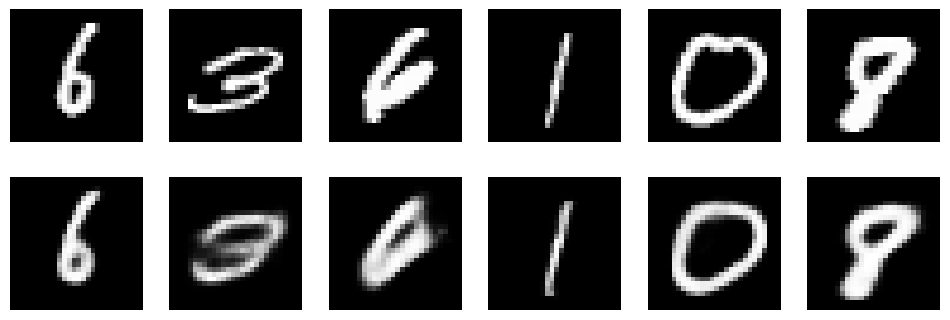

In [9]:
import matplotlib.pyplot as plt
iamges, _ = next(iter(train_loader))  # Getting one batch
images = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    reconstructed, latent = model(images)  # Reconstructed image

original = images.cpu().view(-1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 28, 28)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):

    # Original
    axes[0, i].imshow(original[i], cmap='gray')
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(reconstructed[i], cmap='gray')
    axes[1, i].axis('off')

plt.show()